## Technical Lesson: Deep Learning with Normalization & Regularization


### Step 0: Set Up Your Environment


If needed.

In [11]:
# ! pip install --upgrade tensorflow scikit-learn numpy matplotlib

### Step 1: Import Libraries and Load Data

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
cal_data = fetch_california_housing()
X = cal_data.data
y = cal_data.target

print("Data shape:", X.shape)        # Should be (20640, 8)
print("Target shape:", y.shape)      # Should be (20640,)


Data shape: (20640, 8)
Target shape: (20640,)


### Step 2: Create a Validation Split

In [13]:
# Split into train and test first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Further split train data into train and validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print("Training data shape:", X_train_final.shape)
print("Validation data shape:", X_val.shape)
print("Test data shape:", X_test.shape)


Training data shape: (13209, 8)
Validation data shape: (3303, 8)
Test data shape: (4128, 8)


### Step 3: Normalize the Data

In [14]:
scaler = StandardScaler()
scaler.fit(X_train_final)

X_train_scaled = scaler.transform(X_train_final)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature means:", scaler.mean_)
print("Feature variances:", scaler.var_)


Feature means: [ 3.86893364e+00  2.85672647e+01  5.42040408e+00  1.09433536e+00
  1.42691650e+03  3.02944025e+00  3.56468476e+01 -1.19583303e+02]
Feature variances: [3.57143560e+00 1.58482738e+02 4.48993988e+00 1.45205080e-01
 1.29315681e+06 4.70353691e+01 4.55294423e+00 4.02078197e+00]


### Step 4: Build a Baseline Model (No Regularization)

In [15]:
baseline_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)  # Single output for regression
])

baseline_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae','mse']
)

history_baseline = baseline_model.fit(
    X_train_scaled, y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7931 - mae: 0.5966 - mse: 0.7931 - val_loss: 0.4363 - val_mae: 0.4671 - val_mse: 0.4363
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3813 - mae: 0.4386 - mse: 0.3813 - val_loss: 0.4285 - val_mae: 0.4716 - val_mse: 0.4285
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3679 - mae: 0.4239 - mse: 0.3679 - val_loss: 0.6863 - val_mae: 0.4417 - val_mse: 0.6863
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3470 - mae: 0.4130 - mse: 0.3470 - val_loss: 0.3556 - val_mae: 0.4227 - val_mse: 0.3556
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3319 - mae: 0.4041 - mse: 0.3319 - val_loss: 0.4101 - val_mae: 0.4137 - val_mse: 0.4101
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3304 - mae: 0.3987 - mse: 0.3304 - val_loss: 0.6290 - val_mae: 0.4243 - val_mse: 0.6290
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3616 - mae: 0.3944 - mse: 0.361

### Step 5: Add Batch Normalization

In [16]:
model_bn = keras.Sequential([
    layers.Dense(64, activation='linear', input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(64, activation='linear'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(1)
])

model_bn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae','mse']
)

history_bn = model_bn.fit(
    X_train_scaled, y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.8051 - mae: 0.6268 - mse: 0.8051 - val_loss: 0.5559 - val_mae: 0.5049 - val_mse: 0.5559
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.4352 - mae: 0.4786 - mse: 0.4352 - val_loss: 0.4717 - val_mae: 0.4494 - val_mse: 0.4717
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.4142 - mae: 0.4666 - mse: 0.4142 - val_loss: 0.6864 - val_mae: 0.5501 - val_mse: 0.6864
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3931 - mae: 0.4525 - mse: 0.3931 - val_loss: 1.1113 - val_mae: 0.4769 - val_mse: 1.1113
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3823 - mae: 0.4455 - mse: 0.3823 - val_loss: 0.5761 - val_mae: 0.4957 - val_mse: 0.5761
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3773 - mae: 0.4402 - mse: 0.3773 - val_loss: 0.7035 - val_mae: 0.5714 - val_mse: 0.7035
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3696 - mae: 0.4358 - mse: 0.

### Step 6: Incorporate Regularization (L2 + Dropout)

In [17]:
l2_reg = 1e-4
dropout_rate = 0.3

model_reg = keras.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_reg),
                 input_shape=(X_train.shape[1],)),
    layers.Dropout(dropout_rate),

    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_reg)),
    layers.Dropout(dropout_rate),

    layers.Dense(1)
])

model_reg.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae','mse']
)

history_reg = model_reg.fit(
    X_train_scaled, y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.0820 - mae: 0.7207 - mse: 1.0740 - val_loss: 0.5917 - val_mae: 0.4921 - val_mse: 0.5837
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5966 - mae: 0.5438 - mse: 0.5886 - val_loss: 0.4356 - val_mae: 0.4634 - val_mse: 0.4275
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5355 - mae: 0.5137 - mse: 0.5275 - val_loss: 0.4396 - val_mae: 0.4560 - val_mse: 0.4316
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5123 - mae: 0.5048 - mse: 0.5043 - val_loss: 0.4117 - val_mae: 0.4560 - val_mse: 0.4037
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4929 - mae: 0.4918 - mse: 0.4848 - val_loss: 0.4457 - val_mae: 0.4543 - val_mse: 0.4377
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4683 - mae: 0.4842 - mse: 0.4603 - val_loss: 0.4086 - val_mae: 0.4462 - val_mse: 0.4005
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4522 - mae: 0.4726 - mse: 0.444

### Step 7: Evaluate and Compare Models

In [18]:
print("=== Baseline Model ===")
train_scores = baseline_model.evaluate(X_train_scaled, y_train_final, verbose=0)
val_scores   = baseline_model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"Train MAE: {train_scores[1]:.4f}, Train MSE: {train_scores[2]:.4f}")
print(f"Val   MAE: {val_scores[1]:.4f}, Val   MSE: {val_scores[2]:.4f}")

print("\n=== BatchNorm Model ===")
train_scores_bn = model_bn.evaluate(X_train_scaled, y_train_final, verbose=0)
val_scores_bn   = model_bn.evaluate(X_val_scaled, y_val, verbose=0)
print(f"Train MAE: {train_scores_bn[1]:.4f}, Train MSE: {train_scores_bn[2]:.4f}")
print(f"Val   MAE: {val_scores_bn[1]:.4f}, Val   MSE: {val_scores_bn[2]:.4f}")

print("\n=== Regularized Model (L2 + Dropout) ===")
train_scores_reg = model_reg.evaluate(X_train_scaled, y_train_final, verbose=0)
val_scores_reg   = model_reg.evaluate(X_val_scaled, y_val, verbose=0)
print(f"Train MAE: {train_scores_reg[1]:.4f}, Train MSE: {train_scores_reg[2]:.4f}")
print(f"Val   MAE: {val_scores_reg[1]:.4f}, Val   MSE: {val_scores_reg[2]:.4f}")


=== Baseline Model ===


Train MAE: 0.3041, Train MSE: 0.2008
Val   MAE: 0.3520, Val   MSE: 0.2781

=== BatchNorm Model ===
Train MAE: 0.4402, Train MSE: 0.4732
Val   MAE: 0.4650, Val   MSE: 0.6658

=== Regularized Model (L2 + Dropout) ===
Train MAE: 0.3558, Train MSE: 0.2858
Val   MAE: 0.3864, Val   MSE: 0.5917


### Step 8: Test Set for Final Performance

In [19]:
# Regularized Model (L2 + Dropout)
model_reg = tf.keras.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(1)
])

model_reg.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', 'mse']
)

model_reg.fit(
    X_train_scaled, y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    verbose=0
)
test_scores_reg = model_reg.evaluate(X_test_scaled, y_test, verbose=0)
print("\n[Regularized Model on Test Set]")
print(f"Test MAE: {test_scores_reg[1]:.4f}, Test MSE: {test_scores_reg[2]:.4f}")



[Regularized Model on Test Set]
Test MAE: 0.3907, Test MSE: 0.3109


### Step 9: Visualize Training Curves

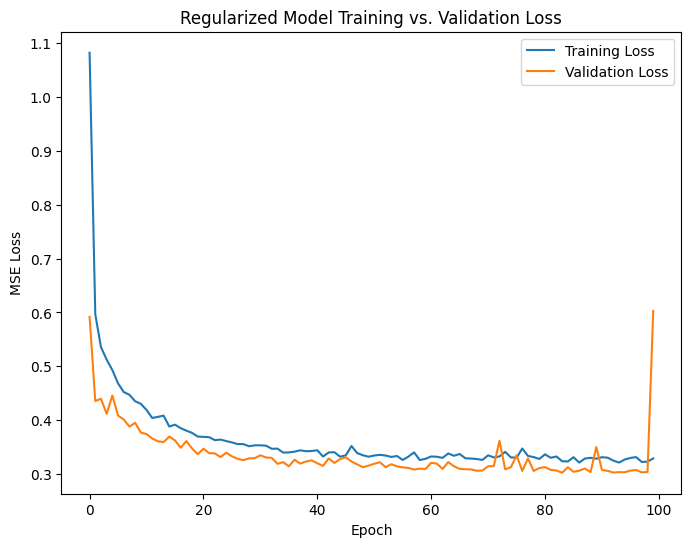

In [20]:
plt.figure(figsize=(8,6))
plt.plot(history_reg.history['loss'], label='Training Loss')
plt.plot(history_reg.history['val_loss'], label='Validation Loss')
plt.title('Regularized Model Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()
